In [7]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt


from electron_integrals import *
from CI_physicist import *

Define functions

In [8]:
# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 
def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_slater_dets):

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Define number of electrons and orbitals

In [11]:
# Number of orbitals (without spin)
num_orbitals = 50
# Number of electrons
num_electrons = 1
#Include spin?
include_spin = False
spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [13]:
x_max = 10
num_points = 1000

x = np.linspace(-x_max,x_max,num_points)

#pot = GaussianWell(w=100, a=1, center=0)
pot = HOPotential()

spf, h = get_spf_and_diag_h(num_orbitals, x, pot)

if include_spin:
    #Add spin
    h = np.kron(h, np.eye(2,2))

# Not used in this code
g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.01)

if include_spin:
    #Add spin
    g = np.kron(g, np.einsum("pr,qs->pqrs",np.eye(2,2), np.eye(2,2)))

print('Sanity test, due to symmetry in g this should be zero:')
print(-g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

Sanity test, due to symmetry in g this should be zero:
0.0


# Only using single particle operators

Solve using Slater-Condon 

In [14]:
zeros = np.zeros_like(g)

H = SlaterCondonHamiltonian(num_spin_orbitals, num_electrons, h, zeros).get_hamiltonian()
E_CI, C_CI = np.linalg.eigh(H)
print(E_CI)
#print(C_CI[:,0].T@H@C_CI[:,0])

#print(C_CI.conj().T@C_CI)

E_exact = E_CI[0]


[ 0.49998747  1.49993737  2.49983716  3.49968685  4.49948641  5.49923587
  6.4989352   7.4985844   8.49818348  9.49773243 10.49723123 11.4966799
 12.49607843 13.49542681 14.49472504 15.49397311 16.49317102 17.49231878
 18.49141636 19.49046378 20.48946102 21.48840809 22.48730497 23.48615167
 24.48494818 25.48369449 26.48239061 27.48103653 28.47963225 29.47817776
 30.47667306 31.47511816 32.47351309 33.471858   34.47015337 35.46840073
 36.46660473 37.46477851 38.46295698 39.46122692 40.45978909 41.45907345
 42.45992515 43.46385429 44.47328565 45.49167785 46.52336769 47.57309818
 48.64537257 49.74389147]


# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [15]:
num_mctdhf_orbitals = 5
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)

#print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

#C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
#C_init[0] = 1

#print(C_init)

Define callable class for the differential equations

In [16]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        self.num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))
        self.I = np.eye(self.num_slater_dets)

    #@numba.jit
    # def get_hs(self, b, h):
    #     h_1 = np.einsum('jm, ij -> im', b, h)
    #     h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    #     h_3 = np.einsum('in, nm -> im', b, h_2)
    #     return h_1, h_2, h_3
        
    
    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_slater_dets)
        bc = b.conj()

        #h_1, h_2, h_3 = self.get_hs(b, h)

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1)
        h_3 = np.einsum('in, nm -> im', b, h_2)

        # h_1 = self.h@b
        # h_2 = bc.T@h_1
        # h_3 = b@h_2

        b_dot = -(h_1-h_3)


        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, np.zeros((self.num_mctdhf_orbitals, )*4)).get_hamiltonian()

        ## From Beck paper, replacing HC with (H-IE)C should keep the wave function normalized (should be able to remove renormalization further down)
        E = C.conj().T@H@C/(C.conj().T@C)
        C_dot = - (H-self.I*E)@C 
    
        ## Regular way
        #C_dot = -H@C


        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [17]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, zeros, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)
bs = [np.copy(b_init)]
bs.append(b_init)

#H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()
Es = np.array([])

t_init = 0
t_final = 3.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-3)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_mctdhf_slater_dets)
    # Normalize every step during imaginary time prop
    #C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))

    ## Test to make sure b_dot is orthogonal to b (otherwise orthonormality will be lost.)  
    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    # h_3 = np.einsum('in, nm -> im', b, h_2)
    # b_dot = -(h_1-h_3)
    # print(f'b@b_dot = \n{b.T.conj()@b_dot}')

    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()

    Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)
    bs.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

Energy deviation =
0.0030344380639362734
Max overlap coeff (ideally zero): 0.0010206576759467921


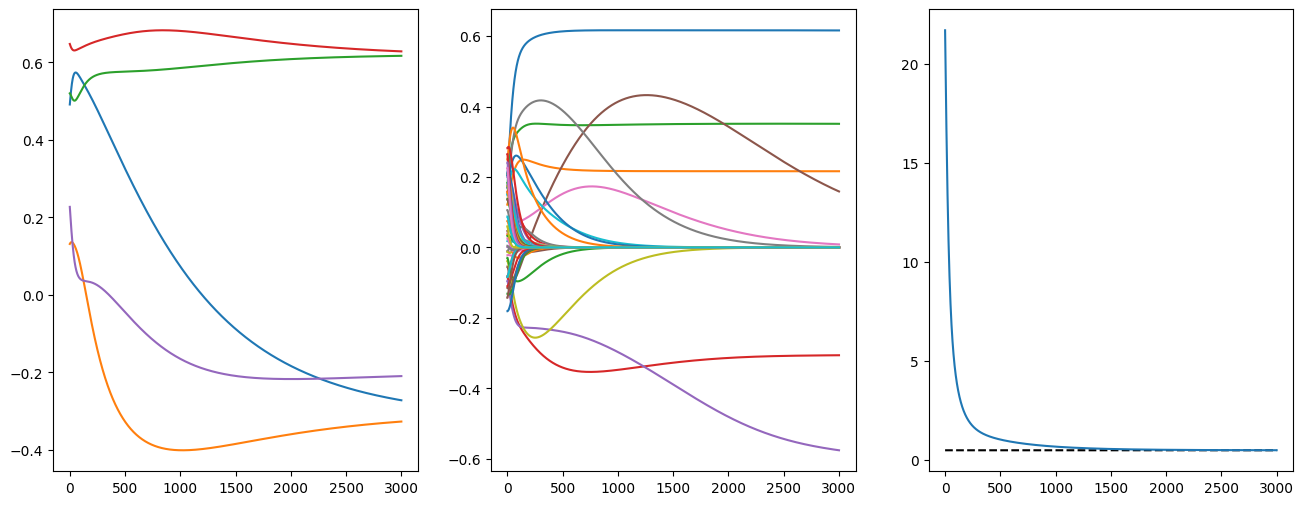

In [18]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_mctdhf_slater_dets)
#print(f"Final b =\n{b_f}")
#print(f"Final C =\n{C_f}")
print(f"Energy deviation =\n{Es[-1]-E_exact}")

#print(f"Overlap matrix for final b:\n{b_f.T@b_f}")

print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")


b_arr = np.array(bs)

fig, ax = plt.subplots(1, 3, figsize=(16,6))
ax[0].plot(np.real(Cs))
ax[1].plot(np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,3]))
ax[2].plot(E_exact*np.ones_like(Es), 'k--')
ax[2].plot(Es)
plt.show()